# Weighted time series forecasting

In many real-world scenarios, historical data is available for forecasting, but not all of it is reliable. For example, IoT sensors capture raw data from the physical world, but they are often prone to failure, malfunction, and attrition due to harsh deployment environments, leading to unusual or erroneous readings. Similarly, factories may shut down for maintenance, repair, or overhaul, resulting in gaps in the data. The COVID-19 pandemic has also affected population behavior, impacting many time series such as production, sales, and transportation.

The presence of unreliable or unrepresentative values in the data history poses a significant challenge, as it hinders model learning. However, most forecasting algorithms require complete time series data, making it impossible to remove these observations. An alternative solution is to reduce the weight of the affected observations during model training. This document demonstrates how **skforecast** makes it easy to implement this strategy with an example.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

The examples that follow demonstrate how a portion of the time series can be excluded from model training by assigning it a weight of zero. However, the use of weights extends beyond the inclusion or exclusion of observations and can also balance the degree of influence that each observation has on the forecasting model. For instance, an observation assigned a weight of 10 will have ten times more impact on the model training than an observation assigned a weight of 1.

</div>

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

In most gradient boosting implementations, such as LightGBM, XGBoost, and CatBoost, samples with zero weight are typically excluded when calculating gradients and Hessians. However, these samples are still taken into account when constructing the feature histograms, which can result in a model that differs from one trained without zero-weighted samples. For more information on this issue, please refer to <a href="https://github.com/lightgbm-org/LightGBM/issues/5553">this GitHub issue</a>.

</div>

## Libraries and data

In [1]:
# Libraries
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster
from skforecast.plot import set_dark_theme

In [2]:
# Data download
# ==============================================================================
url = (
    'https://raw.githubusercontent.com/skforecast/skforecast-datasets/refs/heads/'
    'main/data/energy_production_shutdown.csv'
)
data = pd.read_csv(url, sep=',')

# Data preprocessing
# ==============================================================================
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
data = data.set_index('date')
data = data.sort_index()
data = data.asfreq('D')
data.head()

,production
date,
2012-01-01,375.1
2012-01-02,474.5
2012-01-03,573.9
2012-01-04,539.5
2012-01-05,445.4


In [3]:
# Split data into train-val-test
# ==============================================================================
data = data.loc['2012-01-01 00:00:00': '2014-12-30 23:00:00']
end_train = '2013-12-31 23:59:00'
data_train = data.loc[: end_train, :]
data_test  = data.loc[end_train:, :]

print(
    f"Dates train : {data_train.index.min()} --- {data_train.index.max()}   "
    f"(n={len(data_train)})"
)
print(
    f"Dates test  : {data_test.index.min()} --- {data_test.index.max()}   "
    f"(n={len(data_test)})"
)

Dates train : 2012-01-01 00:00:00 --- 2013-12-31 00:00:00   (n=731)
Dates test  : 2014-01-01 00:00:00 --- 2014-12-30 00:00:00   (n=364)


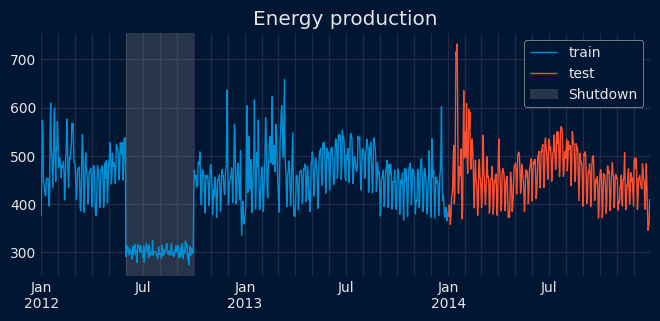

In [4]:
# Time series plot
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(7, 3))
data_train['production'].plot(ax=ax, label='train', linewidth=1)
data_test['production'].plot(ax=ax, label='test', linewidth=1)
ax.axvspan(
    pd.to_datetime('2012-06-01'),
    pd.to_datetime('2012-09-30'),
    label="Shutdown",
    color="gray",
    alpha=0.3
)
ax.set_title('Energy production')
ax.set_xlabel("")
ax.legend();

## Exclude part of the time series

Between 2012-06-01 and 2012-09-30, the factory underwent a shutdown. To reduce the impact of these dates on the model, a custom function is created and passed to the forecaster through the `weight_func` argument. Each time the forecaster is fitted, this function receives the index of the training matrix (the date of the target value of each row) and must return one weight per row.

The function below assigns a weight of 0 to any date that falls within the shutdown period or up to 21 days later, and a weight of 1 to all other dates. The extra 21 days are needed because the forecaster uses `lags = 21`: the rows of the training matrix whose target is dated between 2012-10-01 and 2012-10-21 still use values from the shutdown as predictors, so they are excluded as well. Observations assigned a weight of 0 have no influence on the model training.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

The weights returned by <code>weight_func</code> must be non-negative, must not contain <code>NaN</code> values, and cannot all be zero. If any of these conditions is not met, a <code>ValueError</code> is raised when the forecaster is fitted. The weights of a training set can be inspected with the <a href="https://skforecast.org/latest/api/forecasterrecursive#skforecast.recursive._forecaster_recursive.ForecasterRecursive.create_sample_weights">create_sample_weights</a> method.

</div>

In [5]:
# Custom function to create weights
# ==============================================================================
def custom_weights(index):
    """
    Return a weight of 0 for dates between 2012-06-01 and 2012-10-21
    (shutdown plus the 21 days affected through the lags) and 1 otherwise.
    """
    weights = np.where(
                  (index >= '2012-06-01') & (index <= '2012-10-21'),
                   0,
                   1
              )

    return weights

A [`ForecasterRecursive`](https://skforecast.org/latest/api/forecasterrecursive) is created passing `custom_weights` to the `weight_func` argument. The function is called automatically every time the forecaster is fitted.

In [6]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator   = Ridge(random_state=123),
                 lags        = 21,
                 weight_func = custom_weights
             )

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

If the estimator used in the model's fitting method does not support <code>sample_weight</code> within its <code>fit</code> method, the <code>weight_func</code> argument will be ignored.

</div>

The `source_code_weight_func` attribute of the [`ForecasterRecursive`](https://skforecast.org/latest/api/forecasterrecursive) stores the source code of the function passed as `weight_func`, so it is preserved when the forecaster is saved.

In [7]:
print(forecaster.source_code_weight_func)

def custom_weights(index):
    """
    Return a weight of 0 for dates between 2012-06-01 and 2012-10-21
    (shutdown plus the 21 days affected through the lags) and 1 otherwise.
    """
    weights = np.where(
                  (index >= '2012-06-01') & (index <= '2012-10-21'),
                   0,
                   1
              )

    return weights



After creating the forecaster, a [backtesting process](https://skforecast.org/latest/user_guides/backtesting) is performed with [`backtesting_forecaster`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster) and [`TimeSeriesFold`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._split.TimeSeriesFold) to simulate its behavior if the test set had been predicted in batches of 12 days. With `refit=False`, the model is trained once on the training set (where the weights apply) and then only predicts. If `refit=True`, `weight_func` is called again on every refit to compute the weights of the new training set.

In [8]:
# Backtesting: predict batches of 12 days
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 12,
         initial_train_size = len(data_train),
         refit              = False
     )

metric, predictions_backtest = backtesting_forecaster(
                                   forecaster = forecaster,
                                   y          = data['production'],
                                   cv         = cv,
                                   metric     = 'mean_absolute_error'
                               )

metric

  0%|          | 0/31 [00:00<?, ?it/s]

,mean_absolute_error
0,26.821189


In [9]:
# Backtest predictions
# ==============================================================================
predictions_backtest.head()

,fold,pred
2014-01-01,0,406.122211
2014-01-02,0,444.103631
2014-01-03,0,469.424876
2014-01-04,0,449.407001
2014-01-05,0,414.945674


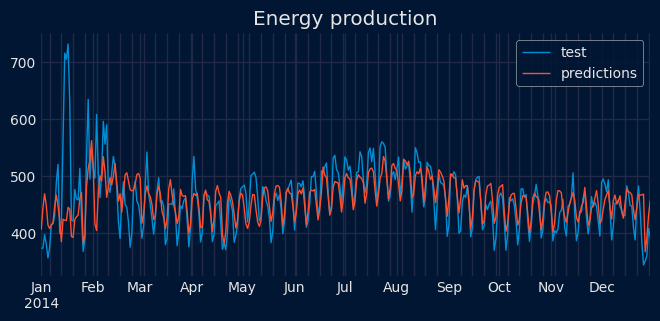

In [10]:
# Predictions plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
data_test['production'].plot(ax=ax, label='test', linewidth=1)
predictions_backtest['pred'].plot(ax=ax, label='predictions', linewidth=1)
ax.set_title('Energy production')
ax.set_xlabel("")
ax.legend();

The model, trained without the influence of the shutdown period, follows the test set closely (mean absolute error of 26.8). In this example, the weights were used only to include or exclude observations, but any non-negative value is allowed: assigning a weight between 0 and 1 to a period reduces its influence on the model without removing it completely, and a weight greater than 1 increases it.